# Tesla Deliveries Forecasting and Sales Analysis using Machine Learning

### Objective
Design and implement an end-to-end machine learning pipeline on Tesla sales/delivery data covering preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, model evaluation, and forecasting.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


# Data Loading and Initial Inspection

In [2]:
df = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
print(df.info())

Dataset Shape:
(2640, 12)

First 5 Rows:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722



Column Names:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  

# Data Cleaning and Quality Checks

In [3]:
print("Missing Values:\n")
print(df.isnull().sum())

print("\n" + "="*50)

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\n" + "="*50)

print("\nStatistical Summary:")
display(df.describe())

Missing Values:

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


Duplicate Rows:
0


Statistical Summary:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


# Date Creation and Time Series Preparation

In [4]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-01'
)

# Sort chronologically
df = df.sort_values('Date')

# Reset index
df = df.reset_index(drop=True)

print("Date column created successfully.\n")

display(
    df[['Date', 'Year', 'Month', 'Estimated_Deliveries']].head()
)

print("\nDate Range:")
print("Start:", df['Date'].min())
print("End  :", df['Date'].max())

Date column created successfully.



,Date,Year,Month,Estimated_Deliveries
0,2015-01-01,2015,1,12446
1,2015-01-01,2015,1,11446
2,2015-01-01,2015,1,8803
3,2015-01-01,2015,1,6367
4,2015-01-01,2015,1,8795



Date Range:
Start: 2015-01-01 00:00:00
End  : 2025-12-01 00:00:00


# Exploratory Data Analysis (EDA)

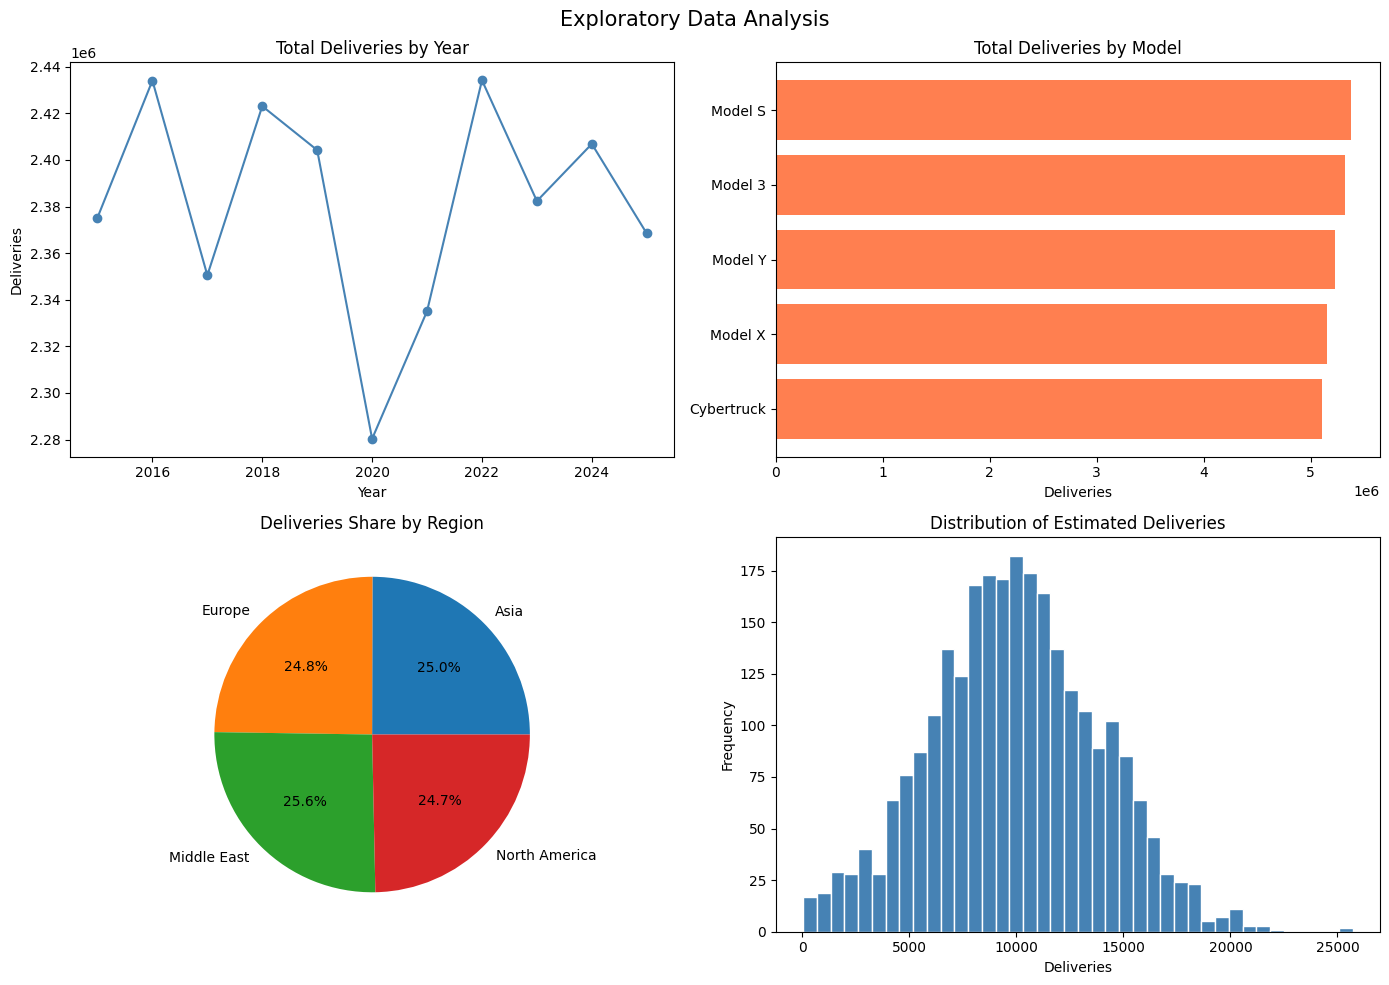

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Total Deliveries by Year

yearly = (
    df.groupby('Year')['Estimated_Deliveries']
      .sum()
      .reset_index()
)

axes[0,0].plot(
    yearly['Year'],
    yearly['Estimated_Deliveries'],
    marker='o',
    color='steelblue'
)

axes[0,0].set_title('Total Deliveries by Year')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Deliveries')

# 2. Total Deliveries by Model

model_totals = (
    df.groupby('Model')['Estimated_Deliveries']
      .sum()
      .sort_values()
)

axes[0,1].barh(
    model_totals.index,
    model_totals.values,
    color='coral'
)

axes[0,1].set_title('Total Deliveries by Model')
axes[0,1].set_xlabel('Deliveries')


# 3. Deliveries by Region

region_totals = (
    df.groupby('Region')['Estimated_Deliveries']
      .sum()
)

axes[1,0].pie(
    region_totals.values,
    labels=region_totals.index,
    autopct='%1.1f%%'
)

axes[1,0].set_title(
    'Deliveries Share by Region'
)

# 4. Distribution of Deliveries

axes[1,1].hist(
    df['Estimated_Deliveries'],
    bins=40,
    color='steelblue',
    edgecolor='white'
)

axes[1,1].set_title('Distribution of Estimated Deliveries')
axes[1,1].set_xlabel('Deliveries')
axes[1,1].set_ylabel('Frequency')


plt.suptitle(
    'Exploratory Data Analysis',
    fontsize=15
)

plt.tight_layout()

plt.show()

# Correlation Analysis

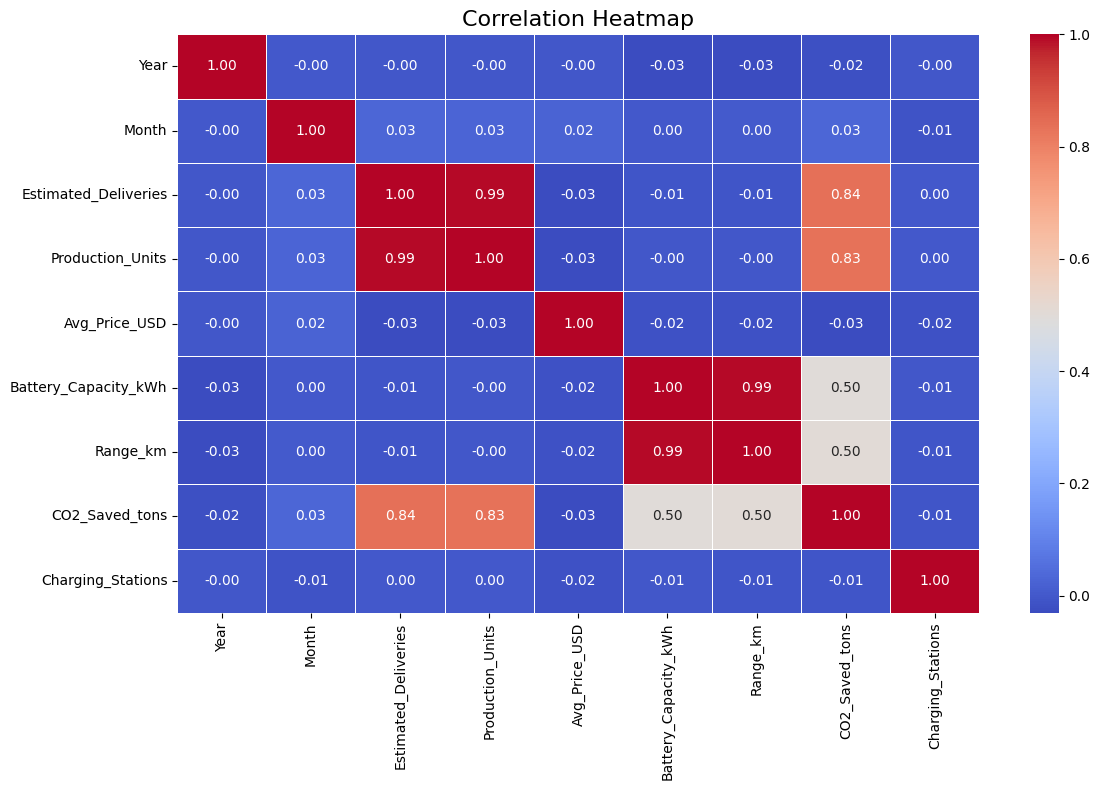

In [6]:
# CORRELATION HEATMAP

plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title(
    'Correlation Heatmap',
    fontsize=16
)

plt.tight_layout()

plt.show()

# Feature Engineering

In [7]:
# Quarter Feature
df['Quarter'] = df['Month'].apply(
    lambda x: (x - 1)//3 + 1
)

# Month Start Indicator
df['Month_Start'] = 1

print("Feature Engineering Completed.\n")

display(
    df[
        [
            'Date',
            'Year',
            'Month',
            'Quarter',
            'Estimated_Deliveries'
        ]
    ].head()
)

Feature Engineering Completed.



,Date,Year,Month,Quarter,Estimated_Deliveries
0,2015-01-01,2015,1,1,12446
1,2015-01-01,2015,1,1,11446
2,2015-01-01,2015,1,1,8803
3,2015-01-01,2015,1,1,6367
4,2015-01-01,2015,1,1,8795


# Encoding Techniques

In [8]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'Region',
        'Model',
        'Source_Type'
    ],
    drop_first=True
)

print("Original Shape :", df.shape)
print("Encoded Shape  :", df_encoded.shape)

print("\nEncoded Columns Created Successfully.\n")

display(df_encoded.head())

Original Shape : (2640, 15)
Encoded Shape  : (2640, 21)

Encoded Columns Created Successfully.



,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date,Quarter,Month_Start,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2015,1,12446,13885,55183.13,60,340,634.75,4390,2015-01-01,1,1,False,False,False,False,False,False,True,False,True
1,2015,1,11446,12752,89289.40,100,588,1009.54,8925,2015-01-01,1,1,False,True,False,True,False,False,False,False,False
2,2015,1,8803,9344,102888.58,60,336,443.67,3923,2015-01-01,1,1,False,True,False,False,False,False,False,True,False
3,2015,1,6367,6802,104962.32,82,459,438.37,9170,2015-01-01,1,1,False,False,True,False,False,False,False,False,False
4,2015,1,8795,9165,87988.73,82,456,601.58,12626,2015-01-01,1,1,False,False,False,True,False,False,False,False,True


# Feature Scaling

In [9]:
# FEATURES AND TARGET

X = df_encoded.drop(
    columns=[
        'Estimated_Deliveries',
        'Date'
    ]
)

y = df_encoded['Estimated_Deliveries']

print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

# FEATURE SCALING

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nFeature Scaling Completed.")

print("\nScaled Data Shape:")
print(X_scaled.shape)

Feature Matrix Shape : (2640, 19)
Target Shape         : (2640,)

Feature Scaling Completed.

Scaled Data Shape:
(2640, 19)


# Chronological Train-Test Split

In [10]:
split_index = int(len(X_scaled) * 0.8)

X_train = X_scaled[:split_index]
X_test = X_scaled[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

print("\nTrain Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

Training Samples : 2112
Testing Samples  : 528

Train Shape : (2112, 19)
Test Shape  : (528, 19)


# Linear Regression Model

In [11]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


# Linear Regression Evaluation

In [12]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Performance\n")

print(f"MAE      : {linear_mae:.2f}")
print(f"RMSE     : {linear_rmse:.2f}")
print(f"R² Score : {linear_r2:.4f}")

Linear Regression Performance

MAE      : 321.43
RMSE     : 390.87
R² Score : 0.9885


# Ridge Regression (L2 Regularization)

In [13]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train,
    y_train
)

ridge_predictions = ridge_model.predict(
    X_test
)

print("Ridge Regression Model Trained Successfully!")

Ridge Regression Model Trained Successfully!


# Ridge Regression Evaluation

In [14]:
ridge_mae = mean_absolute_error(
    y_test,
    ridge_predictions
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_predictions
    )
)

ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)

print("Ridge Regression Performance\n")

print(f"MAE      : {ridge_mae:.2f}")
print(f"RMSE     : {ridge_rmse:.2f}")
print(f"R² Score : {ridge_r2:.4f}")

Ridge Regression Performance

MAE      : 320.93
RMSE     : 390.58
R² Score : 0.9885


# Lasso Regression (L1 Regularization)

In [15]:
lasso_model = Lasso(alpha=1.0)

lasso_model.fit(
    X_train,
    y_train
)

lasso_predictions = lasso_model.predict(
    X_test
)

print("Lasso Regression Model Trained Successfully!")

Lasso Regression Model Trained Successfully!


# Lasso Regression Evaluation

In [16]:
lasso_mae = mean_absolute_error(
    y_test,
    lasso_predictions
)

lasso_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lasso_predictions
    )
)

lasso_r2 = r2_score(
    y_test,
    lasso_predictions
)

print("Lasso Regression Performance\n")

print(f"MAE      : {lasso_mae:.2f}")
print(f"RMSE     : {lasso_rmse:.2f}")
print(f"R² Score : {lasso_r2:.4f}")

Lasso Regression Performance

MAE      : 320.97
RMSE     : 390.44
R² Score : 0.9885


# Model Comparison

In [17]:
comparison_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],
    'MAE': [
        linear_mae,
        ridge_mae,
        lasso_mae
    ],
    'RMSE': [
        linear_rmse,
        ridge_rmse,
        lasso_rmse
    ],
    'R2 Score': [
        linear_r2,
        ridge_r2,
        lasso_r2
    ]
})

comparison_df = comparison_df.round(4)

display(comparison_df)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,321.4330,390.8695,0.9885
1,Ridge Regression,320.9308,390.5771,0.9885
2,Lasso Regression,320.9708,390.4407,0.9885


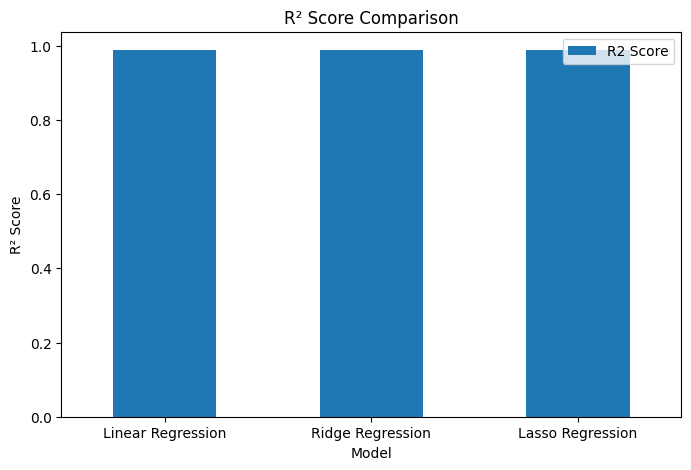

In [18]:
comparison_df.plot(
    x='Model',
    y='R2 Score',
    kind='bar',
    figsize=(8,5)
)

plt.title('R² Score Comparison')

plt.ylabel('R² Score')

plt.xticks(rotation=0)

plt.show()

# Bias-Variance and Overfitting Analysis

This section evaluates model generalization by comparing training and testing performance.

Interpretation:

- If Train R² ≫ Test R² → Overfitting
- If Train R² ≈ Test R² → Good Generalization
- If both Train R² and Test R² are low → Underfitting

A small difference between training and testing performance indicates that the model generalizes well to unseen data.

In [19]:
# Linear Regression
linear_train_r2 = r2_score(
    y_train,
    linear_model.predict(X_train)
)

linear_test_r2 = linear_r2

# Ridge Regression
ridge_train_r2 = r2_score(
    y_train,
    ridge_model.predict(X_train)
)

ridge_test_r2 = ridge_r2

# Lasso Regression
lasso_train_r2 = r2_score(
    y_train,
    lasso_model.predict(X_train)
)

lasso_test_r2 = lasso_r2

overfitting_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],
    'Train R²': [
        linear_train_r2,
        ridge_train_r2,
        lasso_train_r2
    ],
    'Test R²': [
        linear_test_r2,
        ridge_test_r2,
        lasso_test_r2
    ]
})

overfitting_df = overfitting_df.round(4)

display(overfitting_df)

,Model,Train R²,Test R²
0,Linear Regression,0.9908,0.9885
1,Ridge Regression,0.9908,0.9885
2,Lasso Regression,0.9908,0.9885


# Cross Validation using TimeSeriesSplit

In [20]:
tscv = TimeSeriesSplit(n_splits=5)

ridge_cv_scores = cross_val_score(
    Ridge(alpha=1.0),
    X_scaled,
    y,
    cv=tscv,
    scoring='r2'
)

print("Time Series Cross Validation R² Scores:\n")
print(ridge_cv_scores)

print("\nMean R² Score:")
print(round(ridge_cv_scores.mean(), 4))

print("\nStandard Deviation:")
print(round(ridge_cv_scores.std(), 4))

Time Series Cross Validation R² Scores:

[0.99094438 0.99026446 0.99107226 0.99038189 0.98866821]

Mean R² Score:
0.9903

Standard Deviation:
0.0009


# Hyperparameter Tuning (Ridge Regression)

In [21]:
param_grid = {
    'alpha': [
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

grid_search = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='r2'
)

grid_search.fit(
    X_scaled,
    y
)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation R²:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'alpha': 1}

Best Cross Validation R²:
0.9903


# Data Leakage Check

Data leakage occurs when information from the future is unintentionally used during model training, resulting in overly optimistic performance.

To prevent data leakage in the forecasting section, all forecasting features are created using only historical observations.

### Lag Features
- Lag_1
- Lag_3
- Lag_6
- Lag_12

### Rolling Statistics
- Rolling_Mean_3
- Rolling_Mean_6
- Rolling_Std_3

For rolling statistics, `shift(1)` is applied before the rolling calculations. This ensures that the current month's delivery value is never used to predict itself, making the forecasting process realistic and leakage-free.

# Time Series Components

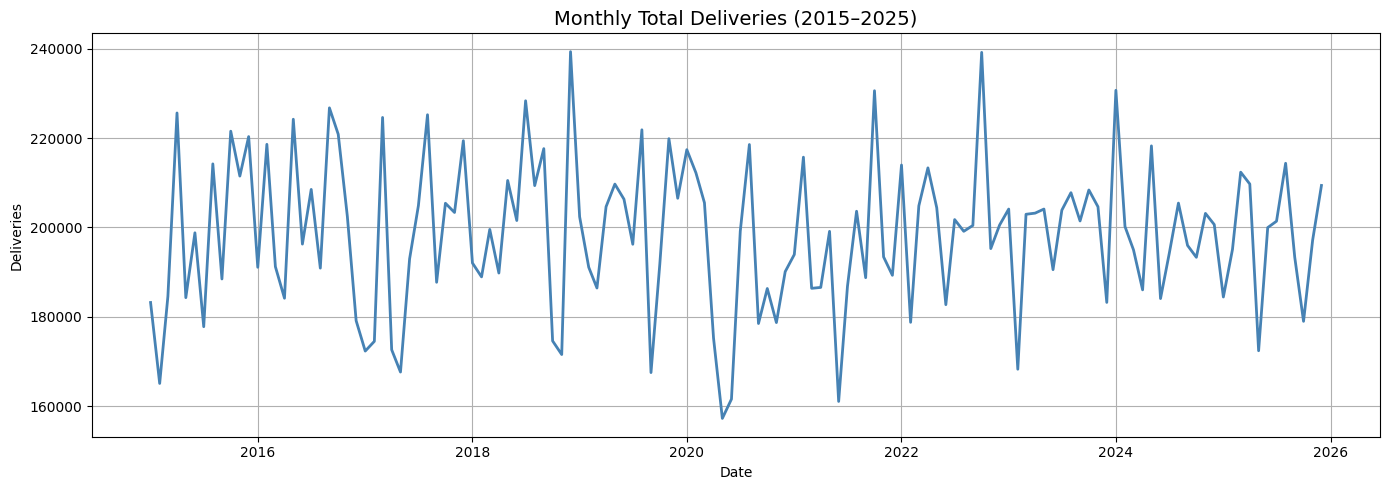

In [22]:
# MONTHLY DELIVERY TIME SERIES

ts = (
    df.groupby(['Year', 'Month'])['Estimated_Deliveries']
      .sum()
      .reset_index()
)

ts['Date'] = pd.to_datetime(
    ts[['Year', 'Month']].assign(Day=1)
)

ts = ts.sort_values('Date')

plt.figure(figsize=(14,5))

plt.plot(
    ts['Date'],
    ts['Estimated_Deliveries'],
    color='steelblue',
    linewidth=2
)

plt.title(
    'Monthly Total Deliveries (2015–2025)',
    fontsize=14
)

plt.xlabel('Date')
plt.ylabel('Deliveries')

plt.grid(True)

plt.tight_layout()

plt.show()

# Forecasting Feature Engineering

In [23]:
# MONTHLY TIME SERIES DATA

ts_df = (
    df.groupby('Date')['Estimated_Deliveries']
      .mean()
      .reset_index()
)

# LAG FEATURES

ts_df['Lag_1'] = ts_df['Estimated_Deliveries'].shift(1)

ts_df['Lag_3'] = ts_df['Estimated_Deliveries'].shift(3)

ts_df['Lag_6'] = ts_df['Estimated_Deliveries'].shift(6)

ts_df['Lag_12'] = ts_df['Estimated_Deliveries'].shift(12)

# ROLLING STATISTICS

ts_df['Rolling_Mean_3'] = (
    ts_df['Estimated_Deliveries']
      .shift(1)
      .rolling(window=3)
      .mean()
)

ts_df['Rolling_Mean_6'] = (
    ts_df['Estimated_Deliveries']
      .shift(1)
      .rolling(window=6)
      .mean()
)

ts_df['Rolling_Std_3'] = (
    ts_df['Estimated_Deliveries']
      .shift(1)
      .rolling(window=3)
      .std()
)

# Remove NaN values
ts_df = ts_df.dropna().reset_index(drop=True)

print("Forecasting Dataset Shape:")
print(ts_df.shape)

display(ts_df.head())

Forecasting Dataset Shape:
(120, 9)


,Date,Estimated_Deliveries,Lag_1,Lag_3,Lag_6,Lag_12,Rolling_Mean_3,Rolling_Mean_6,Rolling_Std_3
0,2016-01-01,9553.45,11016.60,11077.05,8887.95,9159.00,10889.383333,10281.608333,274.366882
1,2016-02-01,10930.00,9553.45,10574.50,10711.15,8252.65,10381.516667,10392.525000,750.422485
2,2016-03-01,9560.40,10930.00,11016.60,9422.40,9228.35,10500.016667,10429.000000,820.893556
3,2016-04-01,9206.70,9560.40,9553.45,11077.05,11281.15,10014.616667,10452.000000,792.752837
4,2016-05-01,11211.00,9206.70,10930.00,10574.50,9213.20,9899.033333,10140.275000,910.189608


# Rolling Statistics

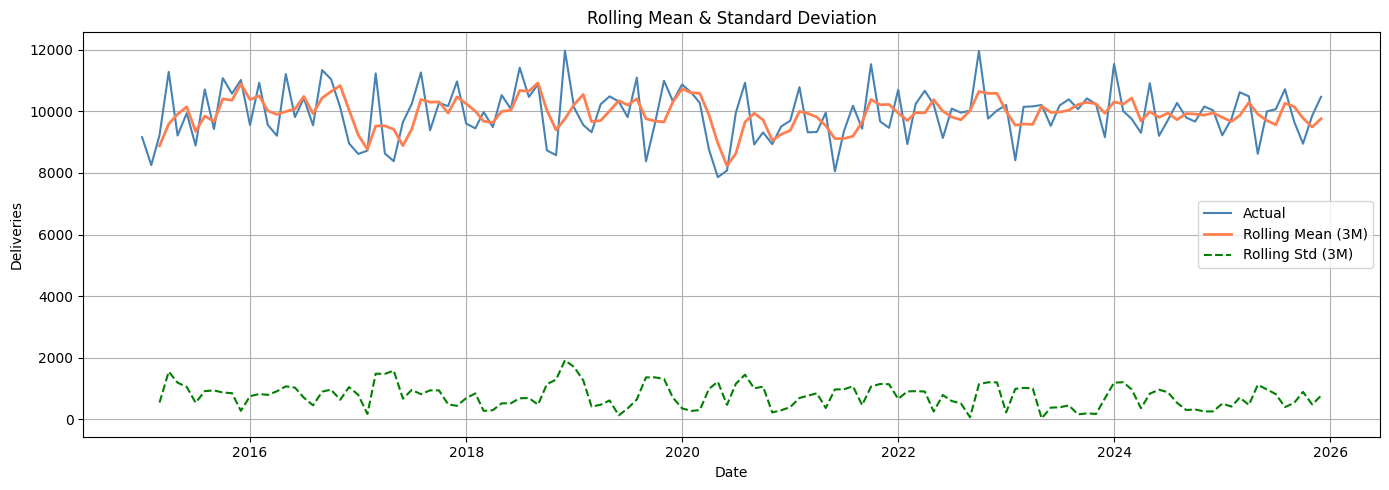

In [24]:
# ROLLING STATISTICS VISUALIZATION

rolling_df = (
    df.groupby('Date')['Estimated_Deliveries']
      .mean()
      .reset_index()
)

rolling_df['Rolling_Mean_3'] = (
    rolling_df['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)

rolling_df['Rolling_Std_3'] = (
    rolling_df['Estimated_Deliveries']
    .rolling(window=3)
    .std()
)

plt.figure(figsize=(14,5))

plt.plot(
    rolling_df['Date'],
    rolling_df['Estimated_Deliveries'],
    label='Actual',
    color='steelblue'
)

plt.plot(
    rolling_df['Date'],
    rolling_df['Rolling_Mean_3'],
    label='Rolling Mean (3M)',
    color='coral',
    linewidth=2
)

plt.plot(
    rolling_df['Date'],
    rolling_df['Rolling_Std_3'],
    label='Rolling Std (3M)',
    color='green',
    linestyle='--'
)

plt.title('Rolling Mean & Standard Deviation')

plt.xlabel('Date')
plt.ylabel('Deliveries')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

# Forecasting Train-Test Split

In [25]:
X_forecast = ts_df[
    [
        'Lag_1',
        'Lag_3',
        'Lag_6',
        'Lag_12',
        'Rolling_Mean_3',
        'Rolling_Mean_6',
        'Rolling_Std_3'
    ]
]

y_forecast = ts_df['Estimated_Deliveries']

# CHRONOLOGICAL SPLIT

split_index = int(len(ts_df) * 0.8)

X_train_f = X_forecast[:split_index]
X_test_f = X_forecast[split_index:]

y_train_f = y_forecast[:split_index]
y_test_f = y_forecast[split_index:]

print("Training Samples:", len(X_train_f))
print("Testing Samples :", len(X_test_f))

print("\nTrain Shape:", X_train_f.shape)
print("Test Shape :", X_test_f.shape)

Training Samples: 96
Testing Samples : 24

Train Shape: (96, 7)
Test Shape : (24, 7)


# Forecasting Model

In [26]:
forecast_model = Ridge(alpha=1)

forecast_model.fit(
    X_train_f,
    y_train_f
)

forecast_predictions = forecast_model.predict(
    X_test_f
)

print("Forecasting Model Trained Successfully!")

Forecasting Model Trained Successfully!


# Forecasting Model Evaluation

In [27]:
forecast_mae = mean_absolute_error(
    y_test_f,
    forecast_predictions
)

forecast_rmse = np.sqrt(
    mean_squared_error(
        y_test_f,
        forecast_predictions
    )
)

forecast_r2 = r2_score(
    y_test_f,
    forecast_predictions
)

print("Forecasting Model Performance\n")

print(f"MAE      : {forecast_mae:.2f}")
print(f"RMSE     : {forecast_rmse:.2f}")
print(f"R² Score : {forecast_r2:.4f}")

Forecasting Model Performance

MAE      : 496.30
RMSE     : 650.71
R² Score : -0.0347


# Forecasting Visualization

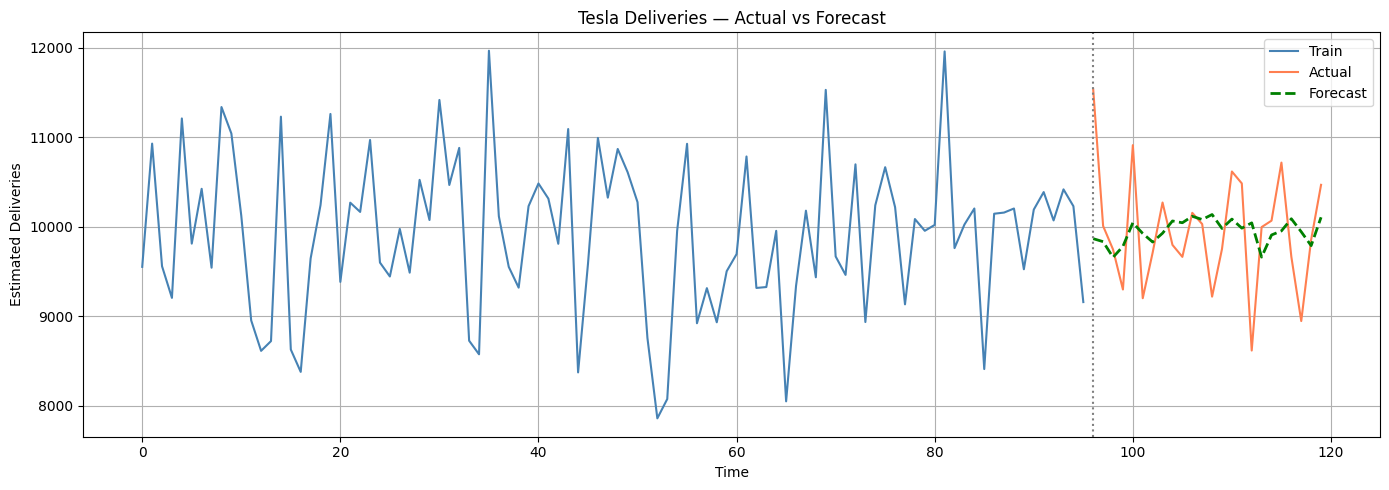

In [28]:
plt.figure(figsize=(14,5))

# Training Data
plt.plot(
    ts_df.index[:len(X_train_f)],
    y_train_f,
    label='Train',
    color='steelblue'
)

# Actual Test Data
plt.plot(
    ts_df.index[len(X_train_f):],
    y_test_f,
    label='Actual',
    color='coral'
)

# Forecast
plt.plot(
    ts_df.index[len(X_train_f):],
    forecast_predictions,
    label='Forecast',
    color='green',
    linestyle='--',
    linewidth=2
)

# Split Line
plt.axvline(
    x=len(X_train_f),
    color='gray',
    linestyle=':',
    linewidth=1.5
)

plt.title('Tesla Deliveries — Actual vs Forecast')

plt.xlabel('Time')
plt.ylabel('Estimated Deliveries')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

# Final Conclusions

- Successfully implemented an end-to-end machine learning pipeline for Tesla deliveries analysis and forecasting.
- Performed data cleaning, exploratory data analysis (EDA), feature engineering, encoding, and feature scaling.
- Strong correlations were identified between **Production Units** and **Estimated Deliveries**.
- Linear Regression, Ridge Regression, and Lasso Regression models were trained and evaluated.
- **Ridge Regression** achieved the best performance with:
  - **R² Score:** 0.9885
  - **MAE:** 320.93
  - **RMSE:** 390.58
- Bias-Variance analysis indicated good generalization with no significant overfitting.
- TimeSeriesSplit cross-validation produced a stable mean **R² Score of 0.9903**.
- Hyperparameter tuning confirmed **alpha = 1** as the optimal Ridge Regression parameter.
- Forecasting was performed using lag features and rolling statistics while preventing data leakage.
- Forecasting performance was limited due to weak temporal dependency in the dataset.
- Overall, the project successfully demonstrates the complete machine learning workflow from preprocessing to forecasting.